In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports (mirrors envelope_variants_test.py)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import gc
import shutil
import pickle
import numpy as np
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
from datetime import datetime

import extract_features
import dutch_30_feature_extractor
import dutch_30_pipeline
import acoustic_change_detector
import run_pipeline

from extract_features import extractHG as _orig_extractHG
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config
from config import DUTCH_30_PATH
from run_pipeline import (
    DEFAULT_RUN_CONFIG,
    run_path_b,
    _run_crf_experiment,
)

ARCHIVE_DIR = 'archive'
os.makedirs(ARCHIVE_DIR, exist_ok=True)

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — pwr_lpf_10 envelope, parameterized by (windowLength, frameshift)
# ═══════════════════════════════════════════════════════════════════════════════

_hilbert3 = lambda x: scipy.signal.hilbert(
    x, scipy.fftpack.next_fast_len(len(x)), axis=0)[:len(x)]


def _bandpass_and_notch(data, sr):
    data = scipy.signal.detrend(data, axis=0)
    sos = scipy.signal.iirfilter(4, [70/(sr/2), 170/(sr/2)],
                                 btype='bandpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos, data, axis=0)
    for f_notch in (100.0, 150.0):
        sos = scipy.signal.iirfilter(4, [(f_notch-2)/(sr/2), (f_notch+2)/(sr/2)],
                                     btype='bandstop', output='sos')
        data = scipy.signal.sosfiltfilt(sos, data, axis=0)
    return data


def _window_average(data, sr, windowLength, frameshift):
    n_win = int(np.floor((data.shape[0] - windowLength * sr) / (frameshift * sr)))
    feat = np.zeros((n_win, data.shape[1]))
    for w in range(n_win):
        s = int(np.floor((w * frameshift) * sr))
        e = int(np.floor(s + windowLength * sr))
        feat[w, :] = np.mean(data[s:e, :], axis=0)
    return feat


def extractHG_pwr_lpf_core(data, sr, windowLength, frameshift,
                           smoothing_hz=10.0):
    """The pwr_lpf envelope — square, low-pass, window-average, sqrt."""
    data = _bandpass_and_notch(data, sr)
    data = data ** 2
    sos_lp = scipy.signal.iirfilter(4, smoothing_hz / (sr / 2),
                                    btype='lowpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos_lp, data, axis=0)
    data = np.abs(data)
    feat = _window_average(data, sr, windowLength, frameshift)
    return np.sqrt(feat)


def make_extractHG(window_ms, shift_ms, smoothing_hz=10.0):
    """Build an extractHG with FIXED window/shift, ignoring pipeline kwargs.

    The pipeline calls extractHG(data, sr, windowLength, frameshift); we
    override those two by binding our own values inside the closure.
    """
    win   = window_ms / 1000.0
    shift = shift_ms  / 1000.0

    def _fn(data, sr, windowLength=None, frameshift=None, debug=False):
        return extractHG_pwr_lpf_core(data, sr, win, shift,
                                      smoothing_hz=smoothing_hz)

    _fn.__name__ = f'extractHG_pwr_lpf_{int(smoothing_hz)}_w{window_ms}_s{shift_ms}'
    return _fn


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Sweep specification
# ═══════════════════════════════════════════════════════════════════════════════
# Each entry: (window_ms, shift_ms, stacking_order).
# stacking_order is rescaled so context = stk * shift  ≈ 50 ms (the original).
# That makes the comparison about "how finely sampled" the envelope is, not
# about how much past/future context the CRF can see.

SWEEP = [
    # window, shift, stk_order   →   fps    context (±ms)   notes
    # ─── Round 1: window × shift at fixed ±50 ms context ─────────────────────
    ( 50,  10,   5),   # 100 fps,  ±50 ms   ← BASELINE (envelope_variants_test default)
    ( 25,  10,   5),   # 100 fps,  ±50 ms   ← shorter window, same fps
    ( 25,   5,  10),   # 200 fps,  ±50 ms   ← finer sampling, same context
    ( 50,   5,  10),   # 200 fps,  ±50 ms   ← finer sampling, original window
    ( 15,   5,  10),   # 200 fps,  ±50 ms   ← short window + fine sampling — current winner
    ( 25,   2,  25),   # 500 fps,  ±50 ms   ← even finer sampling

    # ─── Round 2: extend context with the (w15, s5) winner ───────────────────
    ( 15,   5,  14),   # 200 fps,  ±70 ms   ← match envelope-test context
    ( 15,   5,  20),   # 200 fps, ±100 ms   ← double context
    ( 15,   5,  30),   # 200 fps, ±150 ms   ← phoneme-pair scale

    # ─── Round 3: even shorter window — does the trend hold? ────────────────
    ( 10,   5,  10),   # 200 fps,  ±50 ms   ← w10 with current best context
    ( 10,   5,  20),   # 200 fps, ±100 ms   ← w10 with extended context
    (  7,   5,  20),   # 200 fps, ±100 ms   ← extreme: 7 ms window (~7 raw samples)

    # Half-context variants (test if 50 ms context was too generous) — keep idle
    # (25, 10,  3),    # 100 fps, ±30 ms
    # (25,  5,  5),    # 200 fps, ±25 ms
]

SMOOTHING_HZ = 10.0   # locked to the envelope-sweep winner


In [5]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Cache helpers, patcher, runner
# ═══════════════════════════════════════════════════════════════════════════════

def _tag_for(window_ms, shift_ms, stk_order):
    return f'pwr10_w{window_ms}_s{shift_ms}_stk{stk_order}'


def _archive_caches(tag):
    moved = []
    for fname in ['cache_frames_P21-P30.pkl',
                  'cache_step5_P21-P30_stk5_s1.pkl',
                  'cache_step5_P21-P30_stk7_s1.pkl',
                  'cache_step5_P21-P30_stk7_s2.pkl',
                  'cache_step5_P21-P30_stk10_s1.pkl',
                  'cache_step5_P21-P30_stk25_s1.pkl',
                  'checkpoint_after_step3_P21-P30.pkl']:
        if os.path.exists(fname):
            base, ext = os.path.splitext(fname)
            dst = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
            shutil.move(fname, dst)
            moved.append((fname, dst))
    return moved


def _restore_caches(tag):
    restored = []
    for fname in ['cache_frames_P21-P30.pkl',
                  'cache_step5_P21-P30_stk5_s1.pkl',
                  'cache_step5_P21-P30_stk7_s1.pkl',
                  'cache_step5_P21-P30_stk7_s2.pkl',
                  'cache_step5_P21-P30_stk10_s1.pkl',
                  'cache_step5_P21-P30_stk25_s1.pkl',
                  'checkpoint_after_step3_P21-P30.pkl']:
        base, ext = os.path.splitext(fname)
        cached = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
        if os.path.exists(cached) and not os.path.exists(fname):
            shutil.copy2(cached, fname)
            restored.append((cached, fname))
    return restored


def patch_extractHG(fn):
    for mod in [extract_features,
                dutch_30_feature_extractor,
                dutch_30_pipeline,
                acoustic_change_detector,
                run_pipeline]:
        if hasattr(mod, 'extractHG'):
            mod.extractHG = fn
    print(f"  ✓ extractHG patched to '{fn.__name__}'")


def restore_original():
    for mod in [extract_features,
                dutch_30_feature_extractor,
                dutch_30_pipeline,
                acoustic_change_detector,
                run_pipeline]:
        if hasattr(mod, 'extractHG'):
            mod.extractHG = _orig_extractHG
    print("  ✓ extractHG restored to original")


def run_window_shift(window_ms, shift_ms, stk_order, base_run_config):
    tag = _tag_for(window_ms, shift_ms, stk_order)
    print(f"\n{'='*70}\n  CONFIG: window={window_ms} ms  shift={shift_ms} ms  "
          f"stk_order={stk_order}  ({tag})\n{'='*70}")

    # 1. Stash whatever caches happen to be in root from a prior run
    moved = _archive_caches(tag=f'staging_{datetime.now().strftime("%H%M%S")}')
    for s, d in moved: print(f"    {s} → {d}")

    # 2. Restore caches for this exact (window, shift, stk) config if available
    restored = _restore_caches(tag=tag)
    for s, d in restored: print(f"    restored: {s} → {d}")

    # 3. Patch extractHG to use our chosen window + shift
    patch_extractHG(make_extractHG(window_ms, shift_ms, SMOOTHING_HZ))

    # 4. Build run_config with the matching stacking_order
    run_config = dict(base_run_config)
    run_config['stacking_order']     = stk_order
    run_config['stacking_step_size'] = 1

    # 5. Build pipeline + run path B
    extractor = Dutch30FeatureExtractor()
    pipeline = Dutch30Pipeline(
        dutch30_extractor=extractor,
        debug_mode=False,
        feature_extraction_method=run_config['feature_extraction_method'],
        use_wav2vec=False,
        subtract_baseline=run_config['subtract_baseline'],
        use_rms_boundaries=False,
        use_multifeature=False,
    )
    run_path_b(pipeline, run_config)
    print(f"  Feature shape after stacking: {pipeline.train['features'][0].shape}")

    # 6. CRF
    pipeline.patient_results = {}
    crf_results = _run_crf_experiment(pipeline, run_config)

    accs, lifts, summary = [], [], {}
    for pid, r in crf_results.items():
        n_cl = len(set(r['true_labels']))
        chance = 1.0 / n_cl if n_cl > 0 else 0
        lift = r['accuracy'] / chance if chance > 0 else 0
        accs.append(r['accuracy']); lifts.append(lift)
        summary[pid] = {'accuracy': r['accuracy'], 'lift': lift, 'n_classes': n_cl}
        print(f"    {pid}: acc={r['accuracy']:.3f}  lift={lift:.2f}x")
    print(f"  MEAN: acc={np.mean(accs):.3f}  lift={np.mean(lifts):.2f}x")

    # 7. Archive caches under this config's tag so reruns are instant
    moved_after = _archive_caches(tag=tag)
    for src, dst in moved_after:
        shutil.copy2(dst, src)

    return {
        'window_ms':   window_ms,
        'shift_ms':    shift_ms,
        'stk_order':   stk_order,
        'tag':         tag,
        'accs':        accs,
        'lifts':       lifts,
        'mean_acc':    float(np.mean(accs)),
        'mean_lift':   float(np.mean(lifts)),
        'per_patient': summary,
    }


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — base run_config
# ═══════════════════════════════════════════════════════════════════════════════

base_run_config = dict(DEFAULT_RUN_CONFIG)
base_run_config['use_viterbi']     = True
base_run_config['stacking_step_size'] = 1
# base_run_config['patient_range']    = (21, 30)

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Run the sweep
# ═══════════════════════════════════════════════════════════════════════════════
# First entry (50/10/5) reproduces pwr_lpf_10 from the envelope test — useful
# as a sanity check that this script gives the same number as before.

results = {}
for window_ms, shift_ms, stk_order in SWEEP:
    tag = _tag_for(window_ms, shift_ms, stk_order)
    results[tag] = run_window_shift(window_ms, shift_ms, stk_order, base_run_config)


  CONFIG: window=50 ms  shift=10 ms  stk_order=5  (pwr10_w50_s10_stk5)
  ✓ extractHG patched to 'extractHG_pwr_lpf_10_w50_s10'
Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDic

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Per-patient comparison table
# ═══════════════════════════════════════════════════════════════════════════════

tags = list(results.keys())
pids = sorted(next(iter(results.values()))['per_patient'].keys())

# Short labels for the columns
def short_label(r):
    return f"w{r['window_ms']}/s{r['shift_ms']}"

print("\n" + "="*70)
print("  Per-patient lift comparison (pwr_lpf_10, varying window/shift/stk)")
print("="*70)
labels = [short_label(results[t]) for t in tags]
header = "  pid    " + "".join(f"{l:>11}" for l in labels)
print(header)
print("  " + "-" * (len(header) - 2))
for pid in pids:
    line = f"  {pid:<6} "
    for t in tags:
        lift = results[t]['per_patient'].get(pid, {}).get('lift', float('nan'))
        line += f"{lift:>10.2f}x"
    print(line)
print("  " + "-" * (len(header) - 2))
mean_line = f"  {'mean':<6} "
for t in tags:
    mean_line += f"{results[t]['mean_lift']:>10.2f}x"
print(mean_line)


  Per-patient lift comparison (pwr_lpf_10, varying window/shift/stk)
  pid        w50/s10    w25/s10     w25/s5     w50/s5     w15/s5     w25/s2     w15/s5     w15/s5     w15/s5     w10/s5     w10/s5      w7/s5
  -------------------------------------------------------------------------------------------------------------------------------------------
  P21          2.56x      3.05x      3.81x      2.52x      4.81x      4.64x      5.03x      4.78x      4.42x      4.46x      5.10x      4.96x
  P22          4.47x      5.38x      5.39x      3.79x      5.53x      5.02x      5.73x      5.57x      6.28x      5.86x      5.27x      5.44x
  P23          3.43x      3.78x      4.64x      3.93x      4.82x      4.22x      4.91x      5.37x      5.79x      4.96x      4.82x      5.01x
  P24          2.38x      4.50x      4.44x      2.77x      3.89x      4.07x      4.16x      4.30x      3.89x      4.58x      4.58x      4.93x
  P25          2.00x      3.16x      4.45x      2.43x      4.89x      4.70x   

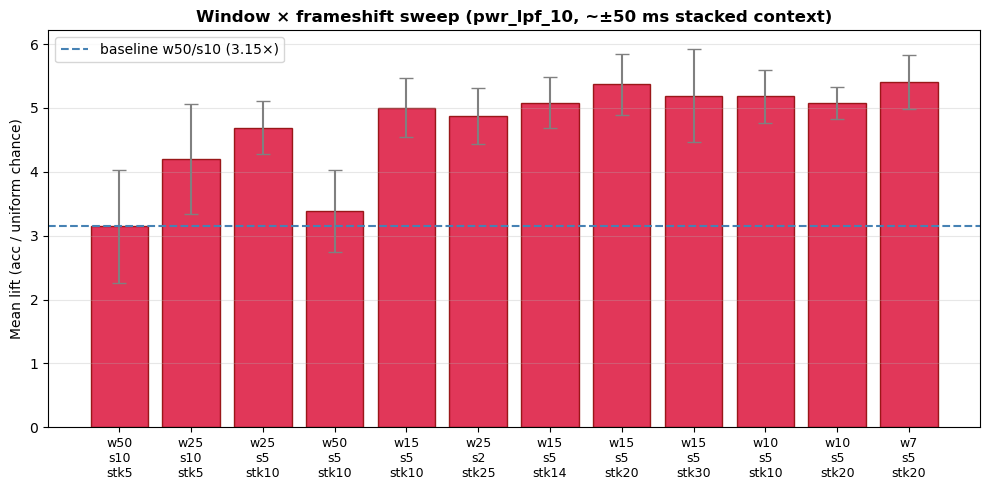

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Mean lift bar chart
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tags))
means = [results[t]['mean_lift']    for t in tags]
sds   = [np.std(results[t]['lifts']) for t in tags]
labels_full = [f"w{results[t]['window_ms']}\ns{results[t]['shift_ms']}\nstk{results[t]['stk_order']}"
               for t in tags]

ax.bar(x, means, yerr=sds, capsize=5, color='crimson', alpha=0.85,
       ecolor='gray', edgecolor='darkred')
ax.set_xticks(x); ax.set_xticklabels(labels_full, fontsize=9)
ax.set_ylabel('Mean lift (acc / uniform chance)')
ax.set_title('Window × frameshift sweep (pwr_lpf_10, ~±50 ms stacked context)',
             fontsize=12, fontweight='bold')
# Reference line at the envelope-sweep baseline
baseline_tag = _tag_for(50, 10, 5)
if baseline_tag in results:
    ax.axhline(results[baseline_tag]['mean_lift'], color='steelblue',
               ls='--', lw=1.5, label=f'baseline w50/s10 ({results[baseline_tag]["mean_lift"]:.2f}×)')
    ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

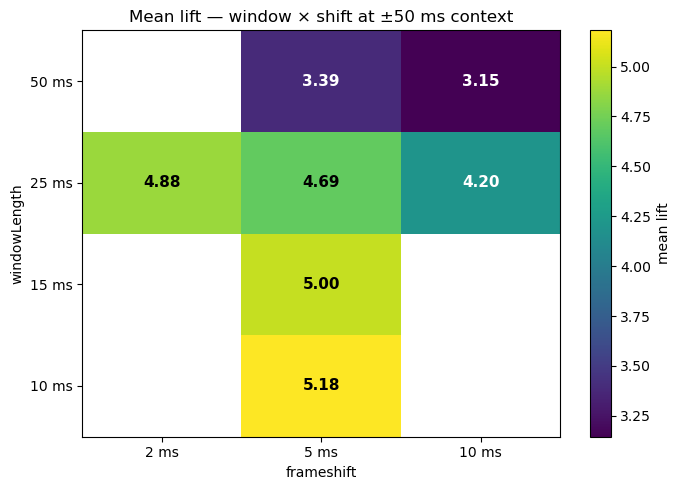

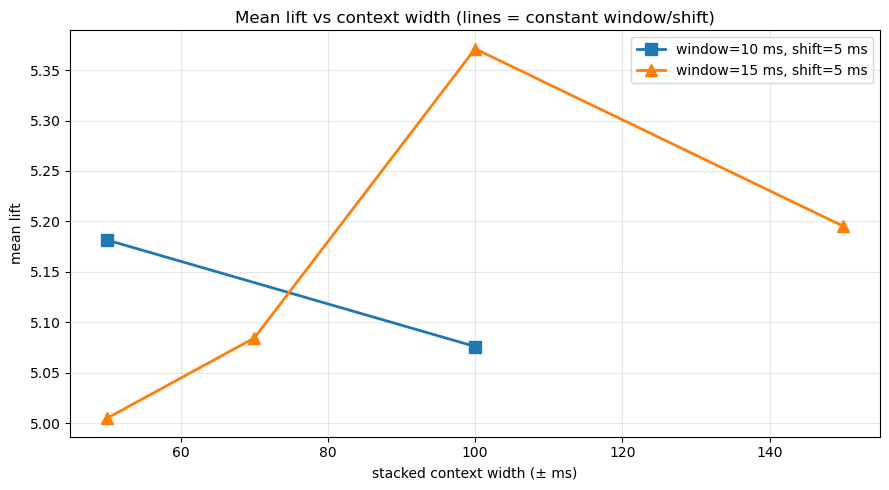

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8b — Two analytical views: (window × shift) and (window × context)
# ═══════════════════════════════════════════════════════════════════════════════
# At ±50 ms context, vary window vs shift.
# At fixed window=15 ms, vary the context width.

# View A: window × shift at ±50 ms context only
view_a = [r for r in results.values()
          if r['stk_order'] * r['shift_ms'] == 50]
if view_a:
    win_vals   = sorted({r['window_ms'] for r in view_a})
    shift_vals = sorted({r['shift_ms']  for r in view_a})
    grid = np.full((len(win_vals), len(shift_vals)), np.nan)
    for r in view_a:
        i = win_vals.index(r['window_ms'])
        j = shift_vals.index(r['shift_ms'])
        grid[i, j] = r['mean_lift']

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(grid, cmap='viridis', aspect='auto', origin='lower')
    ax.set_xticks(range(len(shift_vals)))
    ax.set_xticklabels([f'{s} ms' for s in shift_vals])
    ax.set_yticks(range(len(win_vals)))
    ax.set_yticklabels([f'{w} ms' for w in win_vals])
    ax.set_xlabel('frameshift'); ax.set_ylabel('windowLength')
    ax.set_title('Mean lift — window × shift at ±50 ms context')
    for i in range(len(win_vals)):
        for j in range(len(shift_vals)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        color='white' if v < grid[~np.isnan(grid)].mean() else 'black',
                        fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='mean lift')
    plt.tight_layout(); plt.show()

# View B: context sweep at fixed (w, s)
# Group by (window_ms, shift_ms) and plot mean_lift vs context (= stk * shift)
from collections import defaultdict
ctx_groups = defaultdict(list)
for r in results.values():
    ctx_groups[(r['window_ms'], r['shift_ms'])].append(
        (r['stk_order'] * r['shift_ms'], r['mean_lift']))

fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'P']
for k, ((w, s), pts) in enumerate(sorted(ctx_groups.items())):
    if len(pts) < 2:
        continue
    pts = sorted(pts)
    xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
    ax.plot(xs, ys, marker=markers[k % len(markers)], ms=8, lw=2,
            label=f'window={w} ms, shift={s} ms')
ax.set_xlabel('stacked context width (± ms)')
ax.set_ylabel('mean lift')
ax.set_title('Mean lift vs context width (lines = constant window/shift)')
ax.grid(alpha=0.3)
if any(len(v) >= 2 for v in ctx_groups.values()):
    ax.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Save and restore
# ═══════════════════════════════════════════════════════════════════════════════

out_path = f'window_shift_sweep_results_{datetime.now().strftime("%Y%m%d_%H%M")}.pkl'
to_save = {t: {k: v for k, v in r.items() if k != 'pipeline'}
           for t, r in results.items()}
with open(out_path, 'wb') as f:
    pickle.dump(to_save, f)
print(f"\n  Saved results to {out_path}")

restore_original()